# Markdown file to only look at summary.json files

In [3]:
DEFAULT_SUMMARY_PATH = "/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json"
import pandas as pd

def read_summary_file(path, fold, validation): 
    import json
    with open(path.format(fold=fold, validation=validation), "r") as f:
        return json.load(f)


In [4]:
def read_to_get_num_of_files(dataset, fold):
    path = DEFAULT_SUMMARY_PATH.replace("{validation}", "").replace("summary.json", "").format(input_dataset=dataset, fold=fold)
    
    training_file_path = [f for f in os.listdir(path) if f.startswith("training")]
    print(f"Reading from {path} and found a training file")

    for file in training_file_path:
        with open(os.path.join(path, file), "r") as f:
            lines = f.readlines()
            for line in lines:
                if "This split has" in line:
                    return int(line.strip().split("has")[-1].split("training")[0].strip())
                    break



In [43]:
import os
import json
import pandas as pd
import numpy as np

DEFAULT_SUMMARY_PATH = "/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json"
def read_summary_file(path, fold, validation): 
    with open(path.format(fold=fold, validation=validation), "r") as f:
        return json.load(f)
    

def load_dataset_folds(dataset_num, folds=[f'fold_{i}' for i in range(0, 12)], validation="validation_279"):
    path = DEFAULT_SUMMARY_PATH.format(
        input_dataset=f"Dataset{dataset_num}_AutoPet",
        fold="{fold}",
        validation="{validation}"
    )
    
    summary_dfs = []
    fdg_dfs = []
    psma_dfs = []
    
    for i in folds:
        filepath = path.format(fold=i, validation=validation)
        try:
            fold_data = read_summary_file(path, fold=i, validation=validation)
            num_of_files = read_to_get_num_of_files(f"Dataset{dataset_num}_AutoPet", i)
            # --- Per-case metrics, split by tracer ---
            fdg_rows = []
            psma_rows = []
            
            for case in fold_data['metric_per_case']:
                metrics = case['metrics']['1']
                pred_file = case['prediction_file']
                case_name = os.path.basename(pred_file).replace('.nii.gz', '')
                
                row = {
                    "Dice": metrics['Dice'],
                    "FP":   metrics['FP'],
                    "FN":   metrics['FN'],
                }
                
                if case_name.lower().startswith('fdg'):
                    fdg_rows.append(row)
                elif case_name.lower().startswith('psma'):
                    psma_rows.append(row)
            
            def make_summary_row(rows, fold_label):
                if not rows:
                    return None
                df = pd.DataFrame(rows)
                return pd.DataFrame({
                    "fold":          [fold_label],
                    "Dice":          [round(df['Dice'].mean(), 4)],
                    "FP (voxels)":   [int(df['FP'].sum())],
                    "FN (voxels)":   [int(df['FN'].sum())],
                    "n_cases":       [len(rows)],
                })
            
            # Overall summary from foreground_mean
            df_summary = pd.DataFrame({
                "fold":        [str(i)],
                "Dice":        [round(fold_data['foreground_mean']['Dice'], 4)],
                "FP (voxels)": [sum(c['metrics']['1']['FP'] for c in fold_data['metric_per_case'])],
                "FN (voxels)": [sum(c['metrics']['1']['FN'] for c in fold_data['metric_per_case'])],
                "n_cases":     [len(fold_data['metric_per_case'])],
                "Number_of_files": [num_of_files],
            })
            summary_dfs.append(df_summary)
            
            row_fdg  = make_summary_row(fdg_rows,  str(i))
            row_psma = make_summary_row(psma_rows, str(i))
            if row_fdg  is not None: fdg_dfs.append(row_fdg)
            if row_psma is not None: psma_dfs.append(row_psma)
            
        except Exception as e:
            print(f"Could not read fold {i} for dataset {dataset_num}")
            print(f"Expected path: {filepath}")
            print(f"Error: {e}")
    
    summary_df = pd.concat(summary_dfs, ignore_index=True).sort_values(by='fold', key=lambda x: x.str.extract('(\d+)')[0].astype(int))
    fdg_df     = pd.concat(fdg_dfs,     ignore_index=True).sort_values(by='fold', key=lambda x: x.str.extract('(\d+)')[0].astype(int)) if fdg_dfs  else None
    psma_df    = pd.concat(psma_dfs,    ignore_index=True).sort_values(by='fold', key=lambda x: x.str.extract('(\d+)')[0].astype(int)) if psma_dfs else None
    
    # sort all by 


    return summary_df, fdg_df, psma_df


def display_table(df, title, cmap_dice='RdYlGn', cmap_err='RdYlGn_r'):
    print(f"\n=== {title} ===")
    df_sorted = df.sort_values(by='fold', key=lambda x: x.str.extract('(\d+)')[0].astype(int))
    display(df_sorted.style
        .background_gradient(subset=['Dice'],        cmap=cmap_dice)
        .background_gradient(subset=['FP (voxels)', 'FN (voxels)'], cmap=cmap_err)
        .format({
            'Dice':        '{:.4f}',
            'FP (voxels)': '{:,}',
            'FN (voxels)': '{:,}',
            'n_cases':     '{:,}',
        })
    )

    return df_sorted
# --- Run ---
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    222, validation="validation_279"
)


display_table(summary_df_base, "Overall Summary")
# if fdg_df_base  is not None: display_table(fdg_df_base,  "FDG Only")
# if psma_df_base is not None: display_table(psma_df_base , "PSMA Only")

Could not read fold fold_0 for dataset 222
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json'
Could not read fold fold_1 for dataset 222
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset222_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json'
Could not read f

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_11,0.6497,"557,622","587,074",247,1043


,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_11,0.6497,557622,587074,247,1043


In [45]:
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    223, validation="validation_279"
)


Could not read fold fold_0 for dataset 223
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0/validation_279/summary.json'
Could not read fold fold_1 for dataset 223
Expected path: /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json
Error: [Errno 2] No such file or directory: '/scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset223_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1/validation_279/summary.json'
Could not read f

In [ ]:
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    320, validation="validation_279", folds=[f'fold_{i}' for i in range(0, 6)]
)

d32 = display_table(summary_df_base, "Overall Summary")
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    330, validation="validation_279", folds=[f'fold_{i}' for i in range(0, 6)]
)
d30 = display_table(summary_df_base, "Overall Summary")

summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    333, validation="validation_279", folds=[f'fold_{i}' for i in range(0, 6)]
)
d33 = display_table(summary_df_base, "Overall Summary")





Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset320_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset320_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset320_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset320_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset320_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.6348,"457,719","804,269",247,207
1,fold_1,0.6409,"474,061","727,218",247,208
2,fold_2,0.6383,"435,074","714,271",247,208
3,fold_3,0.6381,"456,166","654,110",247,208
4,fold_4,0.6344,"568,991","694,227",247,208
5,fold_5,0.6372,"513,724","662,620",247,208


Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.6295,"434,272","735,340",247,312
1,fold_1,0.6412,"488,117","706,543",247,312
2,fold_2,0.6574,"505,098","616,538",247,312
3,fold_3,0.6360,"549,023","632,974",247,312
4,fold_4,0.6309,"483,618","729,886",247,312
5,fold_5,0.6450,"486,065","709,153",247,312


Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.6347,"514,986","710,473",247,416
1,fold_1,0.6685,"563,358","560,464",247,417
2,fold_2,0.6553,"494,966","650,453",247,417
3,fold_3,0.6334,"487,966","681,490",247,417
4,fold_4,0.6476,"500,486","544,231",247,417
5,fold_5,0.6499,"501,173","606,534",247,417


In [39]:
d33

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.6347,514986,710473,247,416
1,fold_1,0.6685,563358,560464,247,417
2,fold_2,0.6553,494966,650453,247,417
3,fold_3,0.6334,487966,681490,247,417
4,fold_4,0.6476,500486,544231,247,417
5,fold_5,0.6499,501173,606534,247,417


In [26]:
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    330, validation="validation_279", folds=[f'fold_{i}' for i in range(0, 6)]
)
display_table(summary_df_base, "Overall Summary")



Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset330_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.6295,"434,272","735,340",247,312
1,fold_1,0.6412,"488,117","706,543",247,312
2,fold_2,0.6574,"505,098","616,538",247,312
3,fold_3,0.6360,"549,023","632,974",247,312
4,fold_4,0.6309,"483,618","729,886",247,312
5,fold_5,0.6450,"486,065","709,153",247,312


In [28]:
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    333, validation="validation_279", folds=[f'fold_{i}' for i in range(0, 6)]
)
display_table(summary_df_base, "Overall Summary")



Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset333_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.6347,"514,986","710,473",247,416
1,fold_1,0.6685,"563,358","560,464",247,417
2,fold_2,0.6553,"494,966","650,453",247,417
3,fold_3,0.6334,"487,966","681,490",247,417
4,fold_4,0.6476,"500,486","544,231",247,417
5,fold_5,0.6499,"501,173","606,534",247,417


In [9]:
summary_df_base, fdg_df_base, psma_df_base = load_dataset_folds(
    999, validation="validation_279"
)
# file_count = [9, 51, 103, 114, 155, 207, 312, 416, 521, 625, 729, 1043]

# summary_df_base['Number_of_files'] = file_count
# fdg_df_base['Number_of_files'] = [int(np.round(f * fdg_frac)) for f in file_count]
# psma_df_base['Number_of_files'] = [int(np.round(f * psma_frac)) for f in file_count]



display_table(summary_df_base, "Overall Summary")
if fdg_df_base  is not None: display_table(fdg_df_base,  "FDG Only")
if psma_df_base is not None: display_table(psma_df_base , "PSMA Only")

Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

,fold,Dice,FP (voxels),FN (voxels),n_cases,Number_of_files
0,fold_0,0.3215,"106,399","1,928,574",247,9
1,fold_1,0.5730,"506,133","859,612",247,51
2,fold_2,0.5937,"617,866","806,522",247,103
3,fold_3,0.6167,"616,402","683,630",247,114
4,fold_4,0.6090,"426,337","762,717",247,155
5,fold_5,0.6348,"457,719","804,269",247,207
6,fold_6,0.6295,"434,272","735,340",247,312
7,fold_7,0.6347,"514,986","710,473",247,416
8,fold_8,0.6523,"546,656","608,821",247,521
9,fold_9,0.6587,"603,753","486,774",247,625



=== FDG Only ===


,fold,Dice,FP (voxels),FN (voxels),n_cases
0,fold_0,0.2404,"61,563","1,406,449",151
1,fold_1,0.6541,"325,196","665,584",151
2,fold_2,0.6631,"337,387","660,600",151
3,fold_3,0.6934,"343,252","545,679",151
4,fold_4,0.6950,"293,717","532,123",151
5,fold_5,0.7110,"263,051","629,393",151
6,fold_6,0.7058,"249,122","555,241",151
7,fold_7,0.7173,"312,470","540,881",151
8,fold_8,0.7449,"362,857","428,472",151
9,fold_9,0.7477,"389,400","326,430",151



=== PSMA Only ===


,fold,Dice,FP (voxels),FN (voxels),n_cases
0,fold_0,0.3959,"44,836","522,125",96
1,fold_1,0.4987,"180,937","194,028",96
2,fold_2,0.5301,"280,479","145,922",96
3,fold_3,0.5463,"273,150","137,951",96
4,fold_4,0.5302,"132,620","230,594",96
5,fold_5,0.5650,"194,668","174,876",96
6,fold_6,0.5596,"185,150","180,099",96
7,fold_7,0.5590,"202,516","169,592",96
8,fold_8,0.5674,"183,799","180,349",96
9,fold_9,0.5771,"214,353","160,344",96


In [4]:
summary_df_AL, fdg_df_AL, psma_df_AL = load_dataset_folds(
    111, validation="validation_279"
)
psma_frac = 379/1043
fdg_frac = 664/1043

import numpy as np 

file_count = [103, 114, 155, 207, 312, 416, 521, 625, 729]

summary_df_AL['Number_of_files'] = file_count
fdg_df_AL['Number_of_files'] = [int(np.round(f * fdg_frac)) for f in file_count]
psma_df_AL['Number_of_files'] = [int(np.round(f * psma_frac)) for f in file_count]

display_table(summary_df_AL, "Overall Summary")
display_table(fdg_df_AL,  "FDG Only")
display_table(psma_df_AL , "PSMA Only")

Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset111_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset111_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_1// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset111_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_2// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset111_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_3// and found a training file
Reading from /scratch4/workspace/f007g3j_dartmouth_edu-simple/nnUNet_data/nnUNet_results/Dataset111_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/

ValueError: Length of values (9) does not match length of index (10)

KeyError: 'Number_of_files'

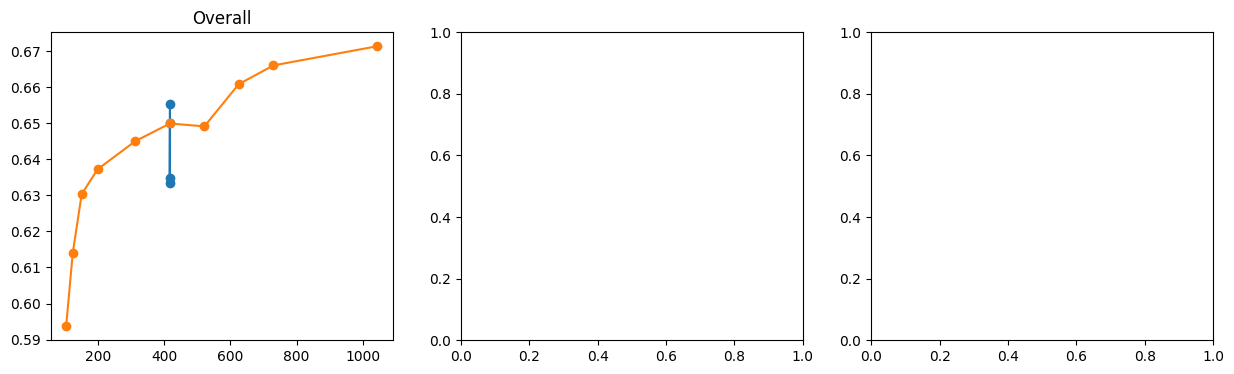

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(summary_df_base['Number_of_files'], summary_df_base['Dice'], marker='o', label='Baseline')
ax[0].plot(summary_df_AL['Number_of_files'], summary_df_AL['Dice'], marker='o', label='Active Learning')
ax[0].set_title("Overall")

ax[1].plot(fdg_df_base['Number_of_files'], fdg_df_base['Dice'], marker='o', label='Baseline')
ax[1].plot(fdg_df_AL['Number_of_files'], fdg_df_AL['Dice'], marker='o', label='Active Learning')
ax[1].set_title("FDG Only")

ax[2].plot(psma_df_base['Number_of_files'], psma_df_base['Dice'], marker='o', label='Baseline')
ax[2].plot(psma_df_AL['Number_of_files'], psma_df_AL['Dice'], marker='o', label='Active Learning')
ax[2].set_title("PSMA Only")    

for a in ax:
    a.set_xlabel('Number of Training Cases')
    a.set_ylabel('Validation Dice Score')


# set legend  outside and make it big
ax[2].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='large')


